In [2]:
"""
2D Amplitude-Stiffness Sweep Analysis
Load and visualize FE sweep results with experimental comparison.
"""

import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from pathlib import Path
from collections import defaultdict

print("✓ Libraries imported")

✓ Libraries imported


In [3]:
"""
Load experimental data for comparison.
"""

def load_experimental_dataset(npz_path, name):
    """Load experimental npz file; returns dict with status and data."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            loaded_dict = {key: data[key] for key in data.files}
            loaded_dict["status"] = "loaded"
            loaded_dict["name"] = name
            return loaded_dict
    except Exception as e:
        return {"name": name, "status": "failed", "error": str(e)}

# Experimental data paths
npz_paths = {
    "Linear low damping": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz",
    "Linear": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear.npz",
    "OC": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz",
    "SC": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz",
    "SC2": r"Z:/Nima/Synthetic_impedance/long_beam/ssdsl_dat/locat_dat_Feb2026/19\lowFreq_SC.npz"
}

exp_data = {}
for name, path in npz_paths.items():
    exp_data[name] = load_experimental_dataset(path.replace("\\", "/"), name)

# Summary
print("Experimental datasets:")
for name, data in exp_data.items():
    if data["status"] == "loaded":
        keys = [k for k in data.keys() if k not in ["status", "name"]]
        print(f"  ✓ {name}: {len(keys)} keys")
    else:
        print(f"  ✗ {name}: {data.get('error', 'unknown error')}")

Experimental datasets:
  ✓ Linear low damping: 2 keys
  ✓ Linear: 2 keys
  ✓ OC: 2 keys
  ✓ SC: 4 keys
  ✓ SC2: 4 keys


In [4]:
"""
Load FE sweep results and plot with experimental overlay.
"""

# ===== User Configuration =====
RUN_FOLDER = "./softening/sweep_1"  # Folder name or absolute path

# ===== Load FE Pickle =====
sim_dat_dir = Path.cwd() / "sim_dat"
run_dir = Path(RUN_FOLDER)
if not run_dir.is_absolute():
    run_dir = sim_dat_dir / RUN_FOLDER

if not run_dir.exists():
    raise FileNotFoundError(f"Run folder not found: {run_dir}")

pickle_candidates = sorted(run_dir.glob("*.pkl"))
if not pickle_candidates:
    raise FileNotFoundError(f"No .pkl file found in: {run_dir}")

pickle_file = pickle_candidates[-1]
print(f"Loading FE data from:\n  {pickle_file}\n")

with open(pickle_file, "rb") as f:
    data = pickle.load(f)

results_by_kc = data["results_by_kc"]
failed = data.get("failed", [])

print(f"FE sweep summary:")
print(f"  Kc cases: {len(results_by_kc)}")
print(f"  Successful: {len(results_by_kc) * len(next(iter(results_by_kc.values())).get('amps', []))}")
print(f"  Failed: {len(failed)}\n")

# ===== Recover Kc Label Order =====
if "Kc_labels" in data:
    kc_labels_sorted = data["Kc_labels"]
elif "Kc_cases" in data:
    kc_labels_sorted = [case["label"] for case in data["Kc_cases"]]
else:
    kc_labels_sorted = sorted(results_by_kc.keys())

# ===== Helper Functions =====
def get_entry(data_block, key, idx):
    """Safely extract list entry."""
    if key not in data_block or idx >= len(data_block[key]):
        return None
    return data_block[key][idx]

def build_curve(data_block, idx):
    """Extract FRF curve from data block."""
    # Try FRF field
    frf = get_entry(data_block, "FRF", idx)
    if frf is not None:
        return np.asarray(frf)
    
    # Try u_dot field
    u_dot = get_entry(data_block, "u_dot", idx)
    if u_dot is not None:
        u_dot = np.asarray(u_dot)
        if u_dot.ndim == 2:
            return np.mean(np.abs(u_dot), axis=1)
        return np.abs(u_dot).squeeze()
    
    # Try Y field
    Y = get_entry(data_block, "Y", idx)
    if Y is not None:
        Y = np.asarray(Y)
        if Y.ndim == 2:
            return np.mean(np.abs(Y), axis=1)
        return np.abs(Y).squeeze()
    
    return None


Loading FE data from:
  c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\softening.pkl

FE sweep summary:
  Kc cases: 5
  Successful: 35
  Failed: 5



In [5]:
"""
Run FE linear simulations: both time-domain and frequency-domain, with variations.
Similar to amp_sweep approach.
"""

# Import FE model if not already imported
import sys
from pathlib import Path
project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import importlib
import Modeling
importlib.reload(Modeling)
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers
import Modeling.models.FE3 as FE_module

# ===== FE Parameters (match sweep setup) =====
params_fe_lin = PiezoBeamParams(
    hp=0.252e-3,
    hs=0.51e-3,
    d31=-1.48e-10,
    eps_r=1700,
)
params_fe_lin.zeta_p = 0.0151 * 8
params_fe_lin.zeta_q = 0.0392 * 10

# Sweep parameters
t_end_lin = 0.01
f0_lin = 1000
f1_lin = 3000
dt_lin = 1 / f1_lin / 50
A_lin = 5.0  # Very low amplitude for linear regime

# ===== Case 1: Kp = 0.032 (normal damping) =====
print("Running FE linear cases...\n")

K_i_lin = 1800
K_c_lin = 0
R_c_lin = 1e3
K_p_norm = 0.015

fe_lin = FE_module.PiezoBeamFE(params_fe_lin)

def v_exc_lin(t):
    return A_lin * np.sin(2 * np.pi * (f0_lin + t * (f1_lin - f0_lin) / t_end_lin) * t)

# ===== Frequency Domain (using frf_sweep) =====
ode_lin = fe_lin.build_ode_system(
    j_exc=30,
    K_c=K_c_lin,
    K_i=K_i_lin,
    K_p=K_p_norm,
    R_c=R_c_lin,
    v_exc=v_exc_lin
)

frf_fd_lin = FE_helpers.frf_sweep(ode_lin, np.linspace(f0_lin, f1_lin, 500) * 2 * np.pi)
fe_cases = {
    "FE_Linear_FD": {
        "freq": frf_fd_lin['freq'],
        "frf": np.mean(np.abs(frf_fd_lin['u_dot']), axis=1),
        "color": "black",
        "style": "-",
        "linewidth": 3,
        "label": f"FE Lin "
    }
}

# ===== Time Domain (using solve_newmark with spectral) =====
out_lin_td = FE_helpers.solve_newmark(
    ode=ode_lin,
    dt=dt_lin,
    t_end=t_end_lin,
    beta=0.25,
    gamma=0.5,
    newton_tol=1e-8,
    newton_maxiter=8,
    x0=np.zeros(ode_lin.M.shape[0]),
    x_dot0=np.zeros(ode_lin.M.shape[0]),
    do_spectral=True
)

fe_cases["FE_Linear_TD"] = {
    "freq": out_lin_td["spectral"]["freq"],
    "frf": out_lin_td["spectral"]["FRF"],
    "color": "darkblue",
    "style": "--",
    "linewidth": 2.5,
    "label": f"FE Lin TD (Kp=0.032)"
}

# ===== Low Damping Case: Kp = 0.001 =====
K_p_low = 0.004

ode_lin_low = fe_lin.build_ode_system(
    j_exc=30,
    K_c=K_c_lin,
    K_i=K_i_lin,
    K_p=K_p_low,
    R_c=R_c_lin,
    v_exc=v_exc_lin
)

frf_fd_lin_low = FE_helpers.frf_sweep(ode_lin_low, np.linspace(f0_lin, f1_lin, 500) * 2 * np.pi)
fe_cases["FE_Linear_LowDamp_FD"] = {
    "freq": frf_fd_lin_low['freq'],
    "frf": np.mean(np.abs(frf_fd_lin_low['u_dot']), axis=1)/1.2,
    "color": "purple",
    "style": "-",
    "linewidth": 2.5,
    "label": f"FE Lin. low damping"
}

out_lin_low_td = FE_helpers.solve_newmark(
    ode=ode_lin_low,
    dt=dt_lin,
    t_end=t_end_lin,
    beta=0.25,
    gamma=0.5,
    newton_tol=1e-8,
    newton_maxiter=8,
    x0=np.zeros(ode_lin_low.M.shape[0]),
    x_dot0=np.zeros(ode_lin_low.M.shape[0]),
    do_spectral=True
)

fe_cases["FE_Linear_LowDamp_TD"] = {
    "freq": out_lin_low_td["spectral"]["freq"],
    "frf": out_lin_low_td["spectral"]["FRF"],
    "color": "mediumpurple",
    "style": "--",
    "linewidth": 2,
    "label": f"FE Lin TD (Kp=0.001)"
}

print("✓ FE linear cases complete:")
for name in fe_cases:
    print(f"  {name}: {len(fe_cases[name]['freq'])} freq points")

Running FE linear cases...



Newmark Integration: 100%|██████████| 1500/1500 [00:02<00:00, 745.19step/s]


X shape: (1501,) Y shape: (1501, 157) freq shape: (1501,) veloc shape: (1501, 157)


Newmark Integration: 100%|██████████| 1500/1500 [00:02<00:00, 713.60step/s]

X shape: (1501,) Y shape: (1501, 157) freq shape: (1501,) veloc shape: (1501, 157)
✓ FE linear cases complete:
  FE_Linear_FD: 500 freq points
  FE_Linear_TD: 751 freq points
  FE_Linear_LowDamp_FD: 500 freq points
  FE_Linear_LowDamp_TD: 751 freq points


Output folder: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots

✓ Plot saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\01_FRF_Kc_0.png


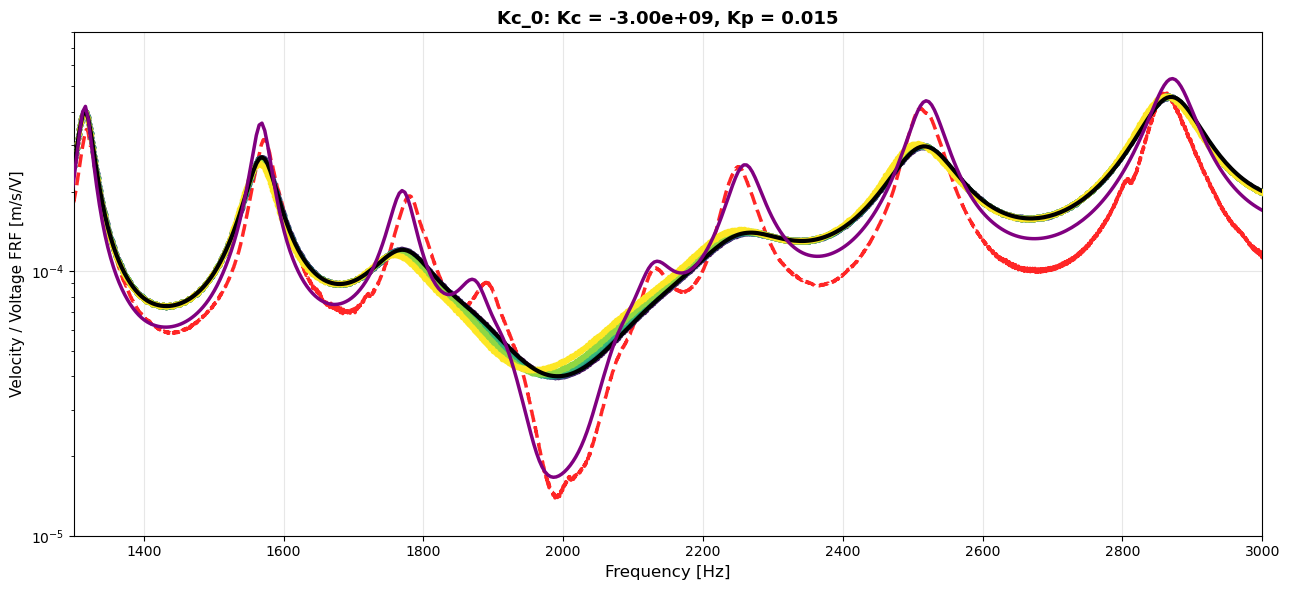

✓ Plot saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\02_FRF_Kc_1.png


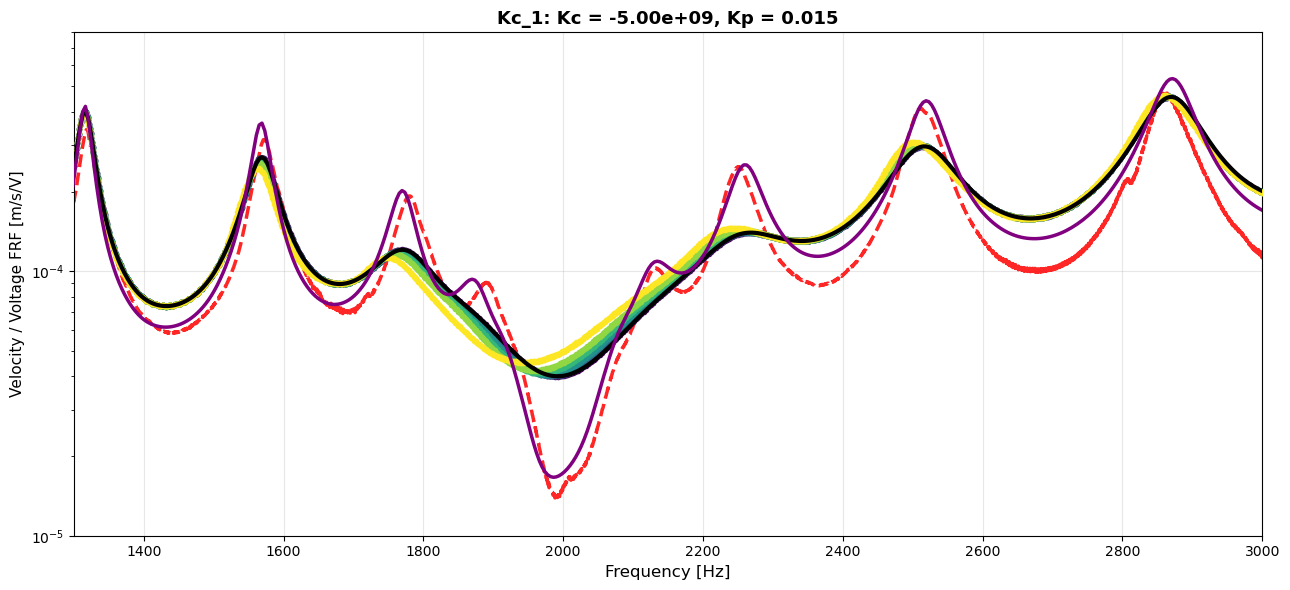

✓ Plot saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\03_FRF_Kc_2.png


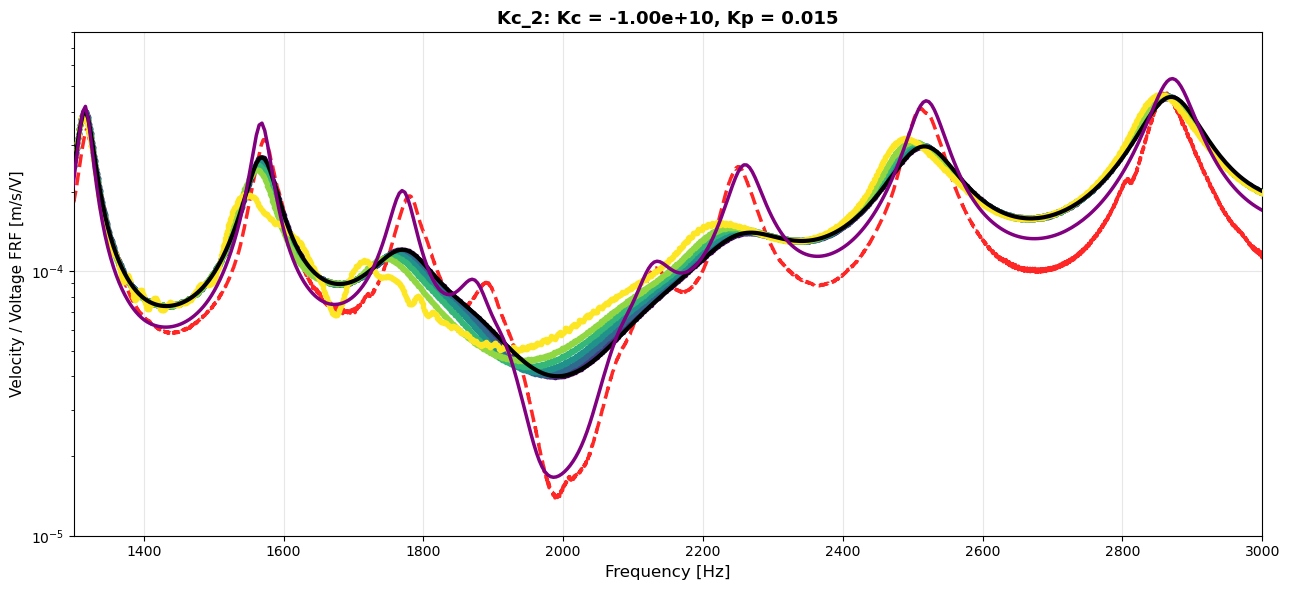

✓ Plot saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\04_FRF_Kc_3.png


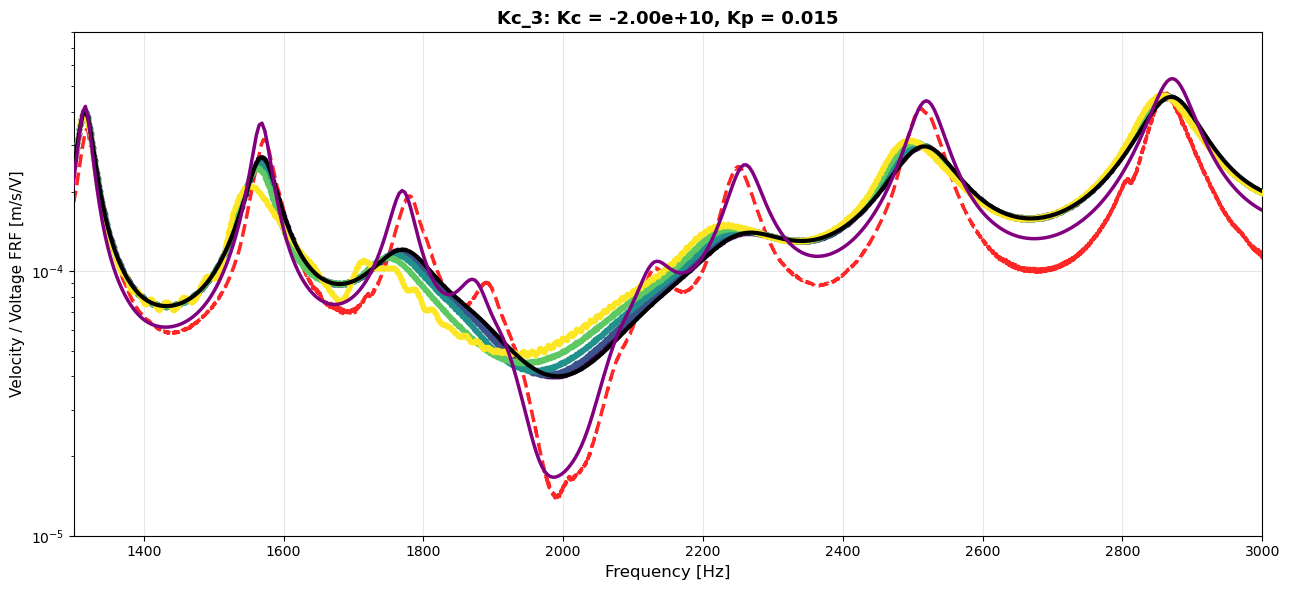

✓ Plot saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\05_FRF_Kc_4.png


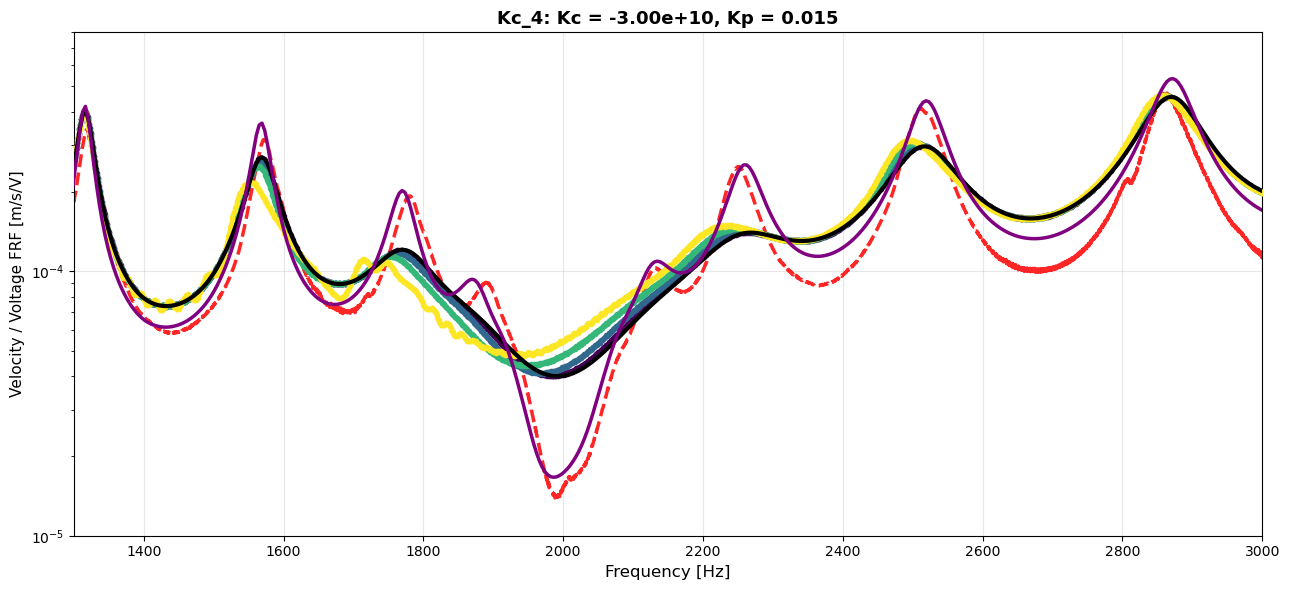

In [6]:
# ===== Configuration: Select which FE linear cases to plot =====
fe_config = {
    "FE_Linear_FD": True,  # Frequency domain, Kp=0.032
    # "FE_Linear_TD": True,  # Time domain, Kp=0.032
    "FE_Linear_LowDamp_FD": True,  # Frequency domain, Kp=0.001 (low damping)
    # "FE_Linear_LowDamp_TD": False,  # Time domain, Kp=0.001
}

# ===== Create output folder for plots =====
plots_dir = run_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
print(f"Output folder: {plots_dir}\n")

# ===== Plot each Kc case in a SEPARATE FIGURE =====
for case_idx, label in enumerate(kc_labels_sorted):
    fig, ax = plt.subplots(1, 1, figsize=(13, 6))
    
    block = results_by_kc[label]
    amps = block["amps"]
    data_block = block["data"]
    freq_list = data_block.get("freq", [])
    
    # ===== Plot FE Sweep Results (colored gradient) =====
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(amps)))
    
    for idx, (amp, col) in enumerate(zip(amps, colors)):
        freq = np.asarray(freq_list[idx]) if idx < len(freq_list) else None
        curve = build_curve(data_block, idx) if idx < len(freq_list) else None
        
        if freq is not None and curve is not None:
            curve = np.asarray(curve).squeeze()
            if len(freq) == len(curve):
                ax.semilogy(freq, curve, '.', color=col, linewidth=2.5, 
                           label=f"FE Sweep: A = {amp:.1f} V", zorder=3)
    
    # ===== Overlay FE Linear Cases (configurable) =====
    for fe_case_name, enabled in fe_config.items():
        if not enabled or fe_case_name not in fe_cases:
            continue
        
        case = fe_cases[fe_case_name]
        ax.semilogy(case["freq"], case["frf"], 
                   color=case["color"], 
                   linestyle=case["style"],
                   linewidth=case["linewidth"],
                   label=case["label"], 
                   zorder=4)
    
    # ===== Overlay Experimental Data =====
    exp_config = {
        "Linear low damping": {"color": "red", "style": "--"},
        # "Linear": {"color": "blue", "style": "-."},
        # "SC": {"color": "green", "style": ":"},
        # "SC2": {"color": "orange", "style": "--"}
    }
    
    for exp_name, config in exp_config.items():
        if exp_name not in exp_data:
            continue
        exp = exp_data[exp_name]
        if exp.get("status") != "loaded":
            continue
        
        try:
            if "freq" not in exp:
                continue
            
            exp_freq = np.asarray(exp["freq"])
            
            # Find FRF field
            frf_field = None
            for field in ["frf_mag", "frf_data", "FRF", "magnitude"]:
                if field in exp:
                    frf_field = exp[field]
                    break
            
            if frf_field is None:
                continue
            
            frf_array = np.asarray(frf_field)
            if frf_array.ndim == 2:
                exp_frf = np.mean(np.abs(frf_array), axis=1)
            else:
                exp_frf = np.abs(frf_array).squeeze()
            
            ax.semilogy(exp_freq, exp_frf, linestyle=config["style"], 
                       color=config["color"], linewidth=2.5, 
                       label=f"Exp: {exp_name}", alpha=0.85, zorder=2)
        
        except Exception as e:
            print(f"  Warning: Could not plot {exp_name}: {e}")
    
    # ===== Labels & Formatting =====
    if "kc_vec" in block and block["kc_vec"] is not None:
        kc_vec = np.asarray(block["kc_vec"])
        title = f"{label}: Kc = {kc_vec[0]:.2e}, Kp = {K_p_norm}"
    else:
        title = label
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Velocity / Voltage FRF [m/s/V]", fontsize=11)
    ax.set_xlabel("Frequency [Hz]", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([1300, 3000])
    ax.set_ylim([1e-5, 8e-4])
    
    plt.tight_layout()
    
    # ===== Save Figure =====
    plot_path = plots_dir / f"0{case_idx + 1}_FRF_{label}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"✓ Plot saved: {plot_path}")
    plt.show()

✓ Legend saved: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\softening\sweep_1\plots\00_legend.png


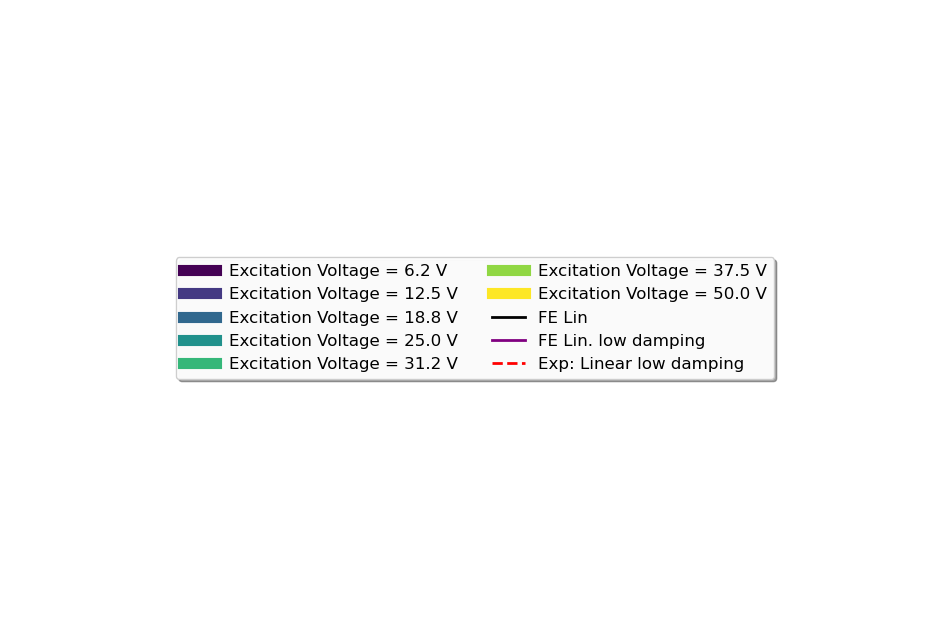

In [7]:
"""
Display legend as a separate figure for clarity.
"""

from matplotlib.lines import Line2D

block = results_by_kc[kc_labels_sorted[0]]
amps = block["amps"]
data_block = block["data"]
freq_list = data_block.get("freq", [])

# Plot FE sweep (show only one amplitude as example for legend)
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(amps)))

# # Plot experimental
# exp_config = {
#     "Linear low damping": {"color": "red", "style": "--"},
#     "Linear ": {"color": "red", "style": "--"}
#     # "SC": {"color": "green", "style": ":"},

# }

# Build thick legend handles manually
legend_handles = []
legend_labels = []

for amp, col in zip(amps, colors):
    legend_handles.append(Line2D([0], [0], color=col, lw=8))
    legend_labels.append(f"Excitation Voltage = {amp:.1f} V")

for fe_case_name, enabled in fe_config.items():
    if not enabled or fe_case_name not in fe_cases:
        continue
    case = fe_cases[fe_case_name]
    legend_handles.append(
        Line2D([0], [0], color=case["color"], lw=2, linestyle=case["style"])
    )
    legend_labels.append(case["label"])

for exp_name, config in exp_config.items():
    legend_handles.append(
        Line2D([0], [0], color=config["color"], lw=2, linestyle=config["style"])
    )
    legend_labels.append(f"Exp: {exp_name}")

# Create a dedicated legend figure
fig_legend = plt.figure(figsize=(12, 8))
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis("off")

# Create legend with custom layout
legend = ax_legend.legend(
    legend_handles, legend_labels,
    loc="center",
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=2,  # 2 columns for better organization
    # title="FRF Components Legend",
    title_fontsize=14
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(0.95)

# plt.tight_layout()

# ===== Save legend figure =====
legend_path = plots_dir / "00_legend.png"
plt.savefig(legend_path, dpi=300, bbox_inches="tight")
print(f"✓ Legend saved: {legend_path}")
plt.show()

In [8]:
from matplotlib.lines import Line2D

# Example: build thick legend handles manually
legend_handles = []
legend_labels = []

# FE sweep colors (thicker)
for amp, col in zip(amps, colors):
    legend_handles.append(Line2D([0], [0], color=col, lw=6))
    legend_labels.append(f"Excitation Voltage = {amp:.1f} V")

# FE linear cases
for fe_case_name, enabled in fe_config.items():
    if not enabled or fe_case_name not in fe_cases:
        continue
    case = fe_cases[fe_case_name]
    legend_handles.append(Line2D([0], [0], color=case["color"],
                                 lw=4, linestyle=case["style"]))
    legend_labels.append(case["label"])

# Experimental
for exp_name, config in exp_config.items():
    legend_handles.append(Line2D([0], [0], color=config["color"],
                                 lw=4, linestyle=config["style"]))
    legend_labels.append(f"Exp: {exp_name}")

legend = ax_legend.legend(
    legend_handles, legend_labels,
    loc="center", ncol=2, fontsize=12, frameon=True, fancybox=True, shadow=True
)

In [9]:
"""
Inspect FE data structure and validate loaded pickle.
"""

print("=== FE Data Structure ===\n")
print(f"Top-level keys: {list(data.keys())}\n")

print(f"Kc cases available: {kc_labels_sorted}\n")

for label in kc_labels_sorted:
    block = results_by_kc[label]
    print(f"{label}:")
    print(f"  Amplitudes: {len(block['amps'])} = {np.array(block['amps']).min():.1f} to {np.array(block['amps']).max():.1f} V")
    print(f"  Data keys: {list(block['data'].keys())}")
    for key in block['data']:
        print(f"    {key}: {len(block['data'][key])} entries")
    if "kc_vec" in block and block["kc_vec"] is not None:
        print(f"  K_c values: {np.asarray(block['kc_vec']).min():.2e} to {np.asarray(block['kc_vec']).max():.2e}")
    print()

=== FE Data Structure ===

Top-level keys: ['Kc_labels', 'results_by_kc', 'failed', 'run_dir', 'K_p', 'K_i']

Kc cases available: ['Kc_0', 'Kc_1', 'Kc_2', 'Kc_3', 'Kc_4']

Kc_0:
  Amplitudes: 7 = 6.2 to 50.0 V
  Data keys: ['freq', 'X', 'Y', 'FRF']
    freq: 7 entries
    X: 7 entries
    Y: 7 entries
    FRF: 7 entries
  K_c values: -3.00e+09 to -3.00e+09

Kc_1:
  Amplitudes: 7 = 6.2 to 50.0 V
  Data keys: ['freq', 'X', 'Y', 'FRF']
    freq: 7 entries
    X: 7 entries
    Y: 7 entries
    FRF: 7 entries
  K_c values: -5.00e+09 to -5.00e+09

Kc_2:
  Amplitudes: 7 = 6.2 to 50.0 V
  Data keys: ['freq', 'X', 'Y', 'FRF']
    freq: 7 entries
    X: 7 entries
    Y: 7 entries
    FRF: 7 entries
  K_c values: -1.00e+10 to -1.00e+10

Kc_3:
  Amplitudes: 5 = 6.2 to 31.2 V
  Data keys: ['freq', 'X', 'Y', 'FRF']
    freq: 5 entries
    X: 5 entries
    Y: 5 entries
    FRF: 5 entries
  K_c values: -2.00e+10 to -2.00e+10

Kc_4:
  Amplitudes: 4 = 6.2 to 25.0 V
  Data keys: ['freq', 'X', 'Y', 'FRF']

Extracted: Kc_0, Amplitude = 6.2 V
  Frequency range: 0 - 75000 Hz
  FRF range: 2.13e-05 - 2.49e-03


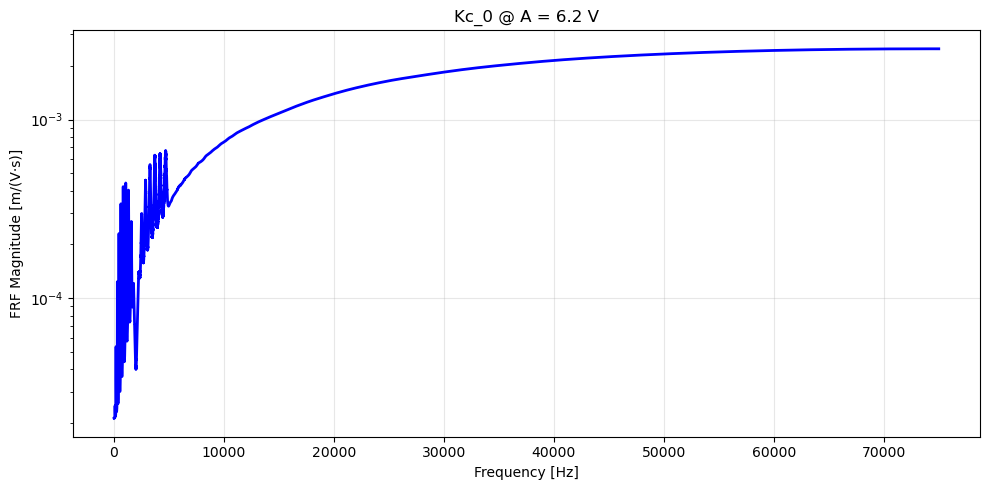

In [10]:
"""
Extract individual FRF for specific amplitude and Kc case.
"""

# Select case
kc_label = kc_labels_sorted[0]  # Change index to select different Kc case
amp_idx = 0  # Change to select different amplitude

block = results_by_kc[kc_label]
freq = np.asarray(block["data"]["freq"][amp_idx])
frf = build_curve(block["data"], amp_idx)
amp_val = block["amps"][amp_idx]

print(f"Extracted: {kc_label}, Amplitude = {amp_val:.1f} V")
print(f"  Frequency range: {freq.min():.0f} - {freq.max():.0f} Hz")
print(f"  FRF range: {np.abs(frf).min():.2e} - {np.abs(frf).max():.2e}")

# Plot single case
plt.figure(figsize=(10, 5))
plt.semilogy(freq, np.abs(frf), 'b-', linewidth=2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF Magnitude [m/(V·s)]")
plt.title(f"{kc_label} @ A = {amp_val:.1f} V")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Heatmap data: Kc_0, A = 6.2 V
  Shape Y: (75001, 157) (freq × nodes)


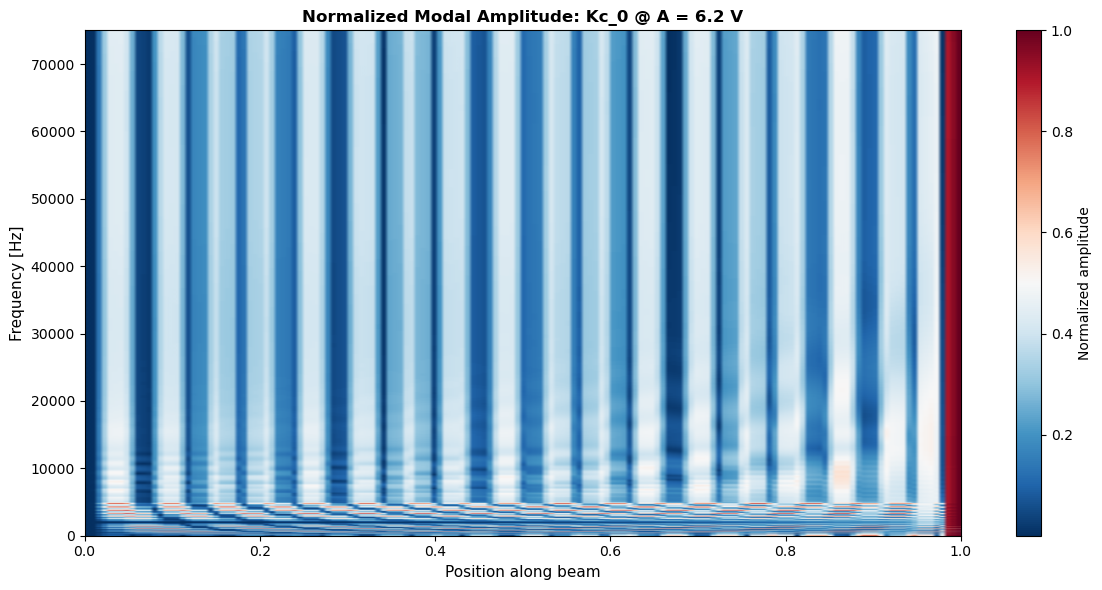

In [11]:
"""
Heatmap: Spatial mode shapes across frequency sweep.
Y shape: (n_freq, n_nodes)
"""

kc_label = kc_labels_sorted[0]
amp_idx = 0  # Amplitude index

block = results_by_kc[kc_label]
freq = np.asarray(block["data"]["freq"][amp_idx])
Y = np.asarray(block["data"]["Y"][amp_idx])

print(f"Heatmap data: {kc_label}, A = {block['amps'][amp_idx]:.1f} V")
print(f"  Shape Y: {Y.shape} (freq × nodes)")

# Magnitude and normalize by frequency
Y_mag = np.abs(Y)
Y_norm = np.zeros_like(Y_mag, dtype=float)
for i in range(Y_mag.shape[0]):
    max_i = np.max(Y_mag[i, :])
    if max_i > 0:
        Y_norm[i, :] = Y_mag[i, :] / max_i

# Node coordinates (0 to 1)
x_nodes = np.linspace(0, 1, Y_mag.shape[1])

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(Y_norm, aspect='auto', origin='lower', cmap='RdBu_r',
              extent=[x_nodes[0], x_nodes[-1], freq.min(), freq.max()])
ax.set_xlabel("Position along beam", fontsize=11)
ax.set_ylabel("Frequency [Hz]", fontsize=11)
ax.set_title(f"Normalized Modal Amplitude: {kc_label} @ A = {block['amps'][amp_idx]:.1f} V", 
            fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized amplitude", fontsize=10)
plt.tight_layout()
plt.show()

Mode shape extraction:
  Case: Kc_0, A = 6.2 V
  Target frequency: 1800.0 Hz → Found: 1800.0 Hz
  Mode shape: 157 nodes


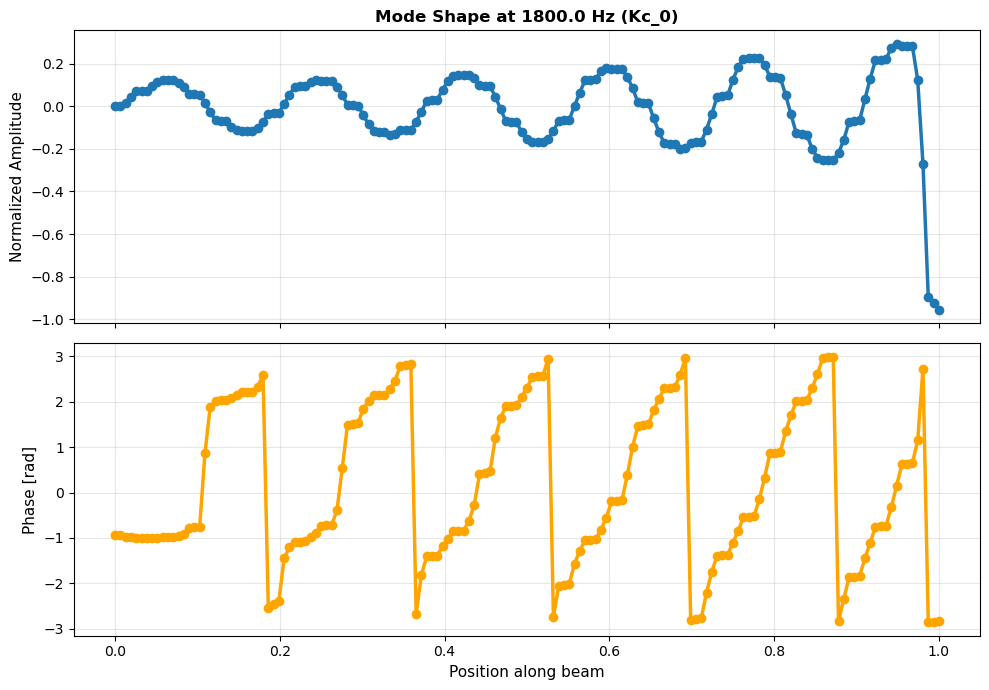

In [12]:
"""
Extract and plot mode shape at specific frequency.
"""

kc_label = kc_labels_sorted[0]
amp_idx = 0
f_target = 1800.0

block = results_by_kc[kc_label]
freq = np.asarray(block["data"]["freq"][amp_idx])
Y = np.asarray(block["data"]["Y"][amp_idx])

# Find closest frequency
f_idx = np.argmin(np.abs(freq - f_target))
f_found = freq[f_idx]
mode_shape = Y[f_idx, :]

print(f"Mode shape extraction:")
print(f"  Case: {kc_label}, A = {block['amps'][amp_idx]:.1f} V")
print(f"  Target frequency: {f_target:.1f} Hz → Found: {f_found:.1f} Hz")
print(f"  Mode shape: {len(mode_shape)} nodes")

# Normalize
phi = mode_shape / (np.max(np.abs(mode_shape)) + 1e-12)
x_nodes = np.linspace(0, 1, len(phi))

# Plot
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(x_nodes, np.real(phi), 'o-', linewidth=2.5, markersize=6)
axs[0].set_ylabel("Normalized Amplitude", fontsize=11)
axs[0].set_title(f"Mode Shape at {f_found:.1f} Hz ({kc_label})", fontsize=12, fontweight='bold')
axs[0].grid(True, alpha=0.3)

axs[1].plot(x_nodes, np.angle(phi), 'o-', linewidth=2.5, markersize=6, color='orange')
axs[1].set_ylabel("Phase [rad]", fontsize=11)
axs[1].set_xlabel("Position along beam", fontsize=11)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

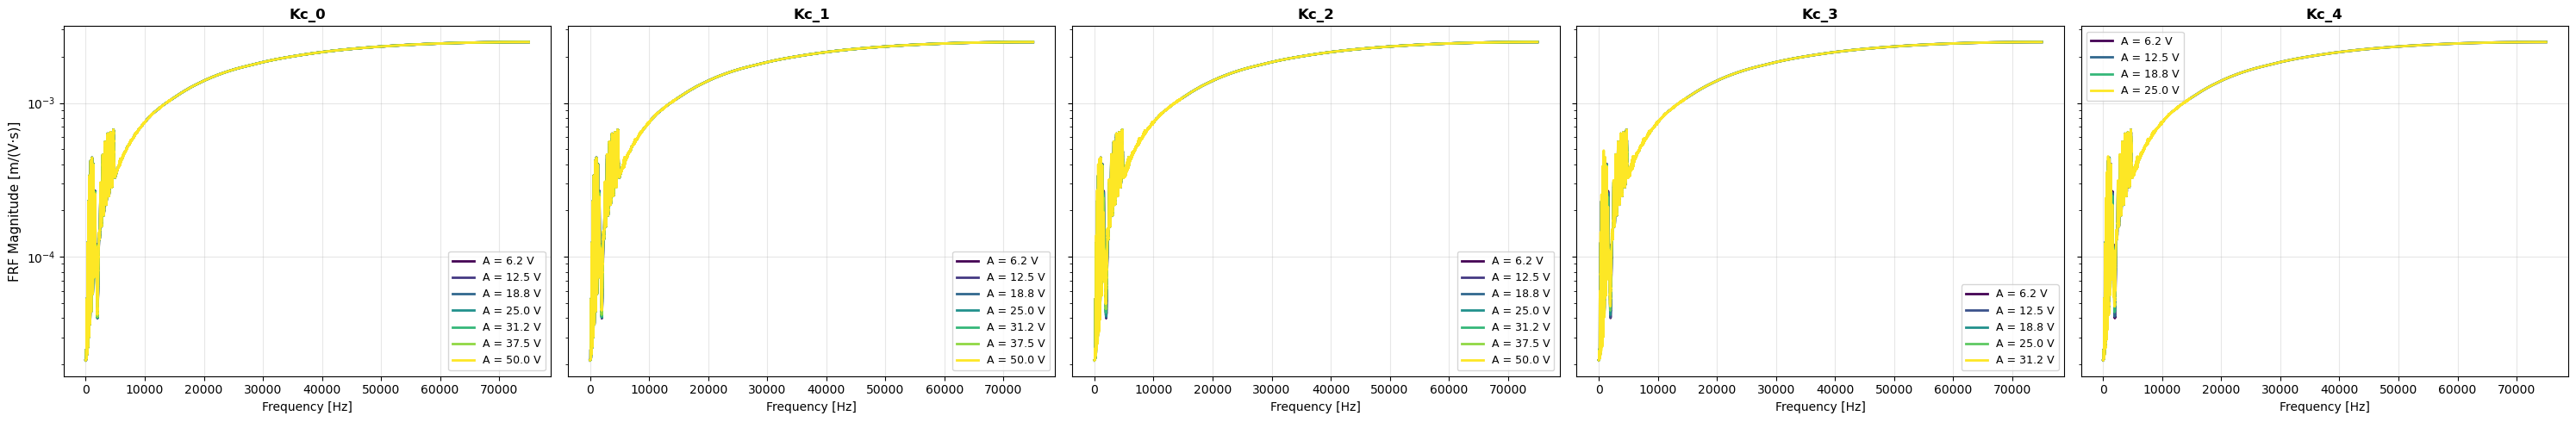

In [13]:
"""
Compare FRF across amplitudes for all Kc cases (side-by-side).
"""

fig, axes = plt.subplots(1, len(kc_labels_sorted), figsize=(6 * len(kc_labels_sorted), 5), sharex=True, sharey=True)

if len(kc_labels_sorted) == 1:
    axes = [axes]

for ax, label in zip(axes, kc_labels_sorted):
    block = results_by_kc[label]
    amps = block["amps"]
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(amps)))
    
    for idx, (amp, col) in enumerate(zip(amps, colors)):
        freq = np.asarray(block["data"]["freq"][idx])
        curve = build_curve(block["data"], idx)
        if curve is not None:
            ax.semilogy(freq, np.abs(curve), color=col, linewidth=2, label=f"A = {amp:.1f} V")
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel("Frequency [Hz]", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

axes[0].set_ylabel("FRF Magnitude [m/(V·s)]", fontsize=11)
plt.tight_layout()
plt.show()